In [62]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/lamborghini-sales-2020-2025/lamborghini_sales_2020_2025.csv


In [63]:
df=pd.read_csv("/kaggle/input/lamborghini-sales-2020-2025/lamborghini_sales_2020_2025.csv")

# **Data Understanding (EDA Start)**

In [64]:
df.head()

,Model,Year,Region,Color,Fuel Type,Base Price (USD),Horsepower,Sales Volume,Turbo (Yes/No)
0,Urus,2020,EMEA,Black,Gasoline,230000,641,4500,Yes
1,Urus,2020,Americas,White,Gasoline,240000,641,4800,Yes
2,Urus,2020,APAC,Red,Gasoline,235000,641,2700,Yes
3,Huracán,2020,EMEA,Yellow,Gasoline,260000,631,2500,Yes
4,Huracán,2020,Americas,Orange,Gasoline,270000,631,2600,Yes


In [65]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54 entries, 0 to 53
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Model             54 non-null     object
 1   Year              54 non-null     int64 
 2   Region            54 non-null     object
 3   Color             54 non-null     object
 4   Fuel Type         54 non-null     object
 5   Base Price (USD)  54 non-null     int64 
 6   Horsepower        54 non-null     int64 
 7   Sales Volume      54 non-null     int64 
 8   Turbo (Yes/No)    54 non-null     object
dtypes: int64(4), object(5)
memory usage: 3.9+ KB


In [66]:
df.isna().sum()

Model               0
Year                0
Region              0
Color               0
Fuel Type           0
Base Price (USD)    0
Horsepower          0
Sales Volume        0
Turbo (Yes/No)      0
dtype: int64

In [67]:
df.shape

(54, 9)

In [68]:
df.duplicated().sum()

np.int64(0)

In [69]:
df.describe()

,Year,Base Price (USD),Horsepower,Sales Volume
count,54.000000,54.000000,54.000000,54.000000
mean,2022.500000,374722.222222,718.277778,2618.037037
std,1.723861,136293.304237,121.645234,1785.625201
min,2020.000000,230000.000000,631.000000,63.000000
25%,2021.000000,265000.000000,631.000000,1187.500000
50%,2022.500000,300000.000000,641.000000,2543.000000
75%,2024.000000,550000.000000,769.000000,3896.500000
max,2025.000000,590000.000000,1001.000000,6200.000000


In [70]:
df.sample(3)

,Model,Year,Region,Color,Fuel Type,Base Price (USD),Horsepower,Sales Volume,Turbo (Yes/No)
51,Huracán (Temerario),2025,EMEA,Grey,Hybrid,380000,850,1300,Yes
46,Revuelto,2025,Americas,Blue,Hybrid,570000,1001,1800,Yes
3,Huracán,2020,EMEA,Yellow,Gasoline,260000,631,2500,Yes


In [71]:
df["Base Price (USD)"].sum()

np.int64(20235000)

In [72]:
df["Sales Volume"].sum()

np.int64(141374)

In [73]:
df["Sales Volume"].mean()

np.float64(2618.037037037037)

In [74]:
df["Horsepower"].max()

1001

In [75]:
df["Model"].max()

'Urus SE'

In [76]:
df["Model"].min()

'Aventador'

In [77]:
df["Color"].max()

'Yellow'

In [78]:
df["Color"].min()

'Black'

In [79]:
df["Fuel Type"].min()

'Gasoline'

# **Sales Analysis** 

In [80]:
df["Base Price (USD)"].max()

590000

In [81]:
df.groupby("Year")["Sales Volume"].sum()

Year
2020    20250
2021    21925
2022    24243
2023    25838
2024    27918
2025    21200
Name: Sales Volume, dtype: int64

# **Revenue Analysis**

In [82]:
df.groupby("Region")["Sales Volume"].sum()

Region
APAC        32043
Americas    55663
EMEA        53668
Name: Sales Volume, dtype: int64

In [83]:
df.groupby("Model")["Sales Volume"].sum().sort_values(ascending=False)

Model
Urus                   54305
Huracán                41481
Urus SE                26812
Revuelto                8956
Aventador               5970
Huracán (Temerario)     3850
Name: Sales Volume, dtype: int64

In [84]:
df["Revenue"] = df["Base Price (USD)"] * df["Sales Volume"]
df["Revenue"].sum()

np.int64(43189580000)

# **Horsepower Analysis**

In [85]:
df.groupby("Model")["Horsepower"].mean()

Model
Aventador               769.0
Huracán                 631.0
Huracán (Temerario)     850.0
Revuelto               1001.0
Urus                    641.0
Urus SE                 641.0
Name: Horsepower, dtype: float64

In [86]:
df[["Horsepower", "Sales Volume"]].corr()

,Horsepower,Sales Volume
Horsepower,1.000000,-0.568689
Sales Volume,-0.568689,1.000000


# **Turbo Impact Analysis**

In [87]:
df.groupby("Turbo (Yes/No)")["Sales Volume"].mean()

Turbo (Yes/No)
Yes    2618.037037
Name: Sales Volume, dtype: float64

# **Visualization**

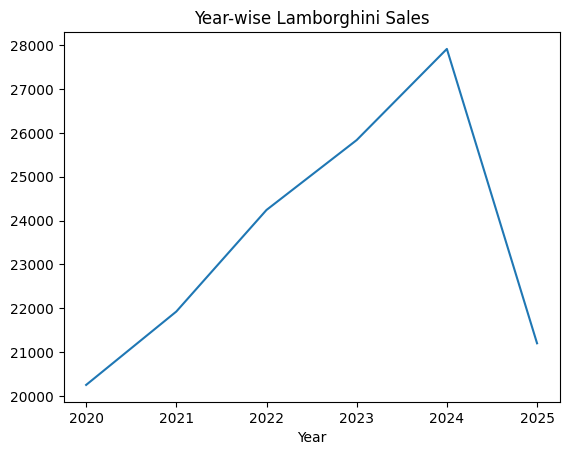

In [88]:
import matplotlib.pyplot as plt

df.groupby("Year")["Sales Volume"].sum().plot(kind="line")
plt.title("Year-wise Lamborghini Sales")
plt.show()

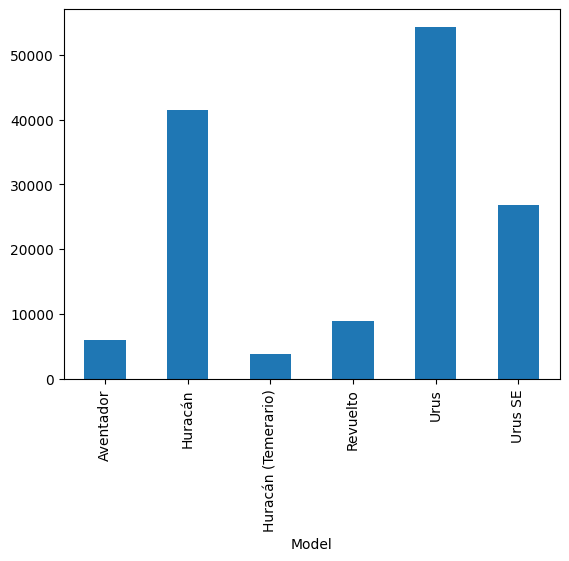

In [89]:
df.groupby("Model")["Sales Volume"].sum().plot(kind="bar")
plt.show()

# **Advanced Analysis**

In [90]:
df.loc[df.groupby("Year")["Sales Volume"].idxmax()]

,Model,Year,Region,Color,Fuel Type,Base Price (USD),Horsepower,Sales Volume,Turbo (Yes/No),Revenue
1,Urus,2020,Americas,White,Gasoline,240000,641,4800,Yes,1152000000
10,Urus,2021,Americas,Black,Gasoline,245000,641,5200,Yes,1274000000
19,Urus,2022,Americas,White,Gasoline,250000,641,5550,Yes,1387500000
28,Urus,2023,Americas,White,Gasoline,260000,641,6200,Yes,1612000000
40,Urus SE,2024,Americas,Silver,Hybrid,320000,641,5800,Yes,1856000000
49,Urus SE,2025,Americas,Black,Hybrid,340000,641,4800,Yes,1632000000


In [91]:
df.groupby("Model")["Revenue"].sum().sort_values(ascending=False)

Model
Urus                   13277465000
Huracán                11602560000
Urus SE                 8618850000
Revuelto                4827000000
Aventador               3380955000
Huracán (Temerario)     1482750000
Name: Revenue, dtype: int64

In [92]:
year_sales = df.groupby("Year")["Sales Volume"].sum()
year_sales = year_sales.reset_index()

In [93]:
year_sales["Year"] = pd.to_datetime(year_sales["Year"], format="%Y")
year_sales.set_index("Year", inplace=True)

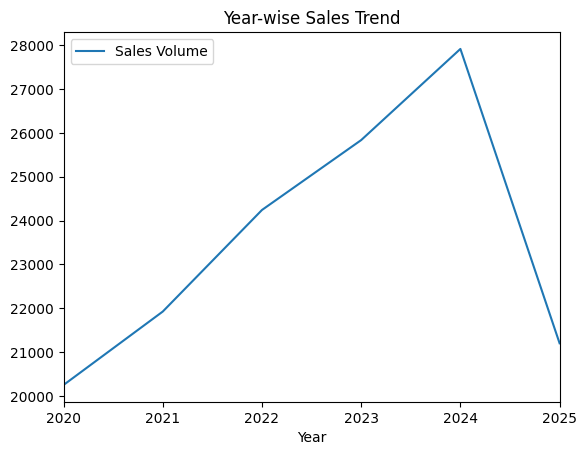

In [94]:
import matplotlib.pyplot as plt

year_sales.plot()
plt.title("Year-wise Sales Trend")
plt.show()

In [95]:
from statsmodels.tsa.arima.model import ARIMA

year_sales = year_sales.asfreq('YS')

model = ARIMA(year_sales["Sales Volume"], order=(1,1,1))
model_fit = model.fit()

forecast = model_fit.forecast(steps=3)
print(forecast)

2026-01-01    21956.584811
2027-01-01    22330.789929
2028-01-01    22515.870924
Freq: YS-JAN, Name: predicted_mean, dtype: float64


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [100]:
model = ARIMA(year_sales["Sales Volume"], order=(0,1,0))
model_fit = model.fit()

forecast = model_fit.forecast(steps=3)
print(forecast)

2026-01-01    21200.0
2027-01-01    21200.0
2028-01-01    21200.0
Freq: YS-JAN, Name: predicted_mean, dtype: float64


In [97]:
from sklearn.linear_model import LinearRegression
import numpy as np

year_sales["Year_num"] = np.arange(len(year_sales))

X = year_sales[["Year_num"]]
y = year_sales["Sales Volume"]

model = LinearRegression()
model.fit(X, y)

future = np.array([[6],[7],[8]])  # Next 3 years
forecast = model.predict(future)

print(forecast)

[25994.73333333 26689.7047619  27384.67619048]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


**ML Model Predict Sales Volume**

In [101]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

X = df[["Base Price (USD)", "Horsepower"]]
y = df["Sales Volume"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = RandomForestRegressor()
model.fit(X_train, y_train)

model.score(X_test, y_test)

0.4319012797475035

In [102]:
df["Turbo_Encoded"] = df["Turbo (Yes/No)"].map({"Yes":1, "No":0})

df = pd.get_dummies(df, columns=["Region", "Fuel Type"], drop_first=True)

X = df.drop(["Sales Volume", "Model", "Color"], axis=1)
y = df["Sales Volume"]

In [103]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [104]:
model = RandomForestRegressor(
    n_estimators=300,
    max_depth=6,
    random_state=42
)

In [106]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
import pandas as pd

X = df[["Base Price (USD)", "Horsepower"]]
y = df["Sales Volume"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

# Feature Importance
importance = pd.Series(model.feature_importances_, index=X.columns)
print(importance.sort_values(ascending=False))

Base Price (USD)    0.561623
Horsepower          0.438377
dtype: float64


<Axes: >

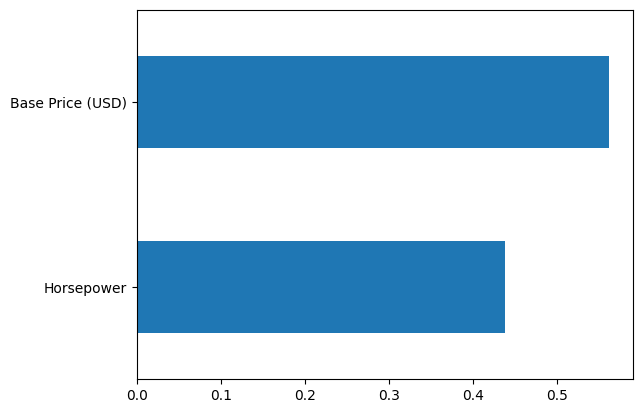

In [107]:
importance.sort_values().plot(kind="barh")